In [3]:
from PIL import Image
import requests
from transformers import AutoProcessor, CLIPVisionModelWithProjection

model = CLIPVisionModelWithProjection.from_pretrained("openai/clip-vit-base-patch32")
model.eval()
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [4]:
from transformers import AutoProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.eval()
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")

In [5]:
from tqdm.auto import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import torch

# Load the colors
df_colors = pd.read_csv('HC_RGB.csv')

# Load the words
with open("random_words.txt", "r") as f:
    words = f.readlines()
words = [l.strip() for l in words]

# Create PIL images from RGB values
color_images = []
for index, row in df_colors.iterrows():
    rgb = (int(row['R']), int(row['G']), int(row['B']))
    img = Image.new('RGB', (256, 256), color=rgb)
    color_images.append(img)

  0%|          | 0/12 [00:00<?, ?it/s]/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].

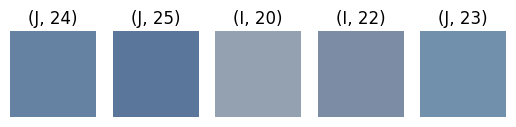

  8%|▊         | 1/12 [00:03<00:37,  3.42s/it]/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_dista

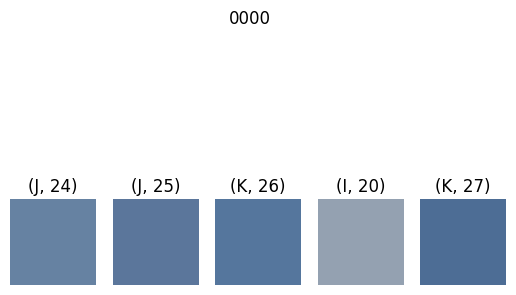

 17%|█▋        | 2/12 [00:06<00:34,  3.41s/it]/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_dista

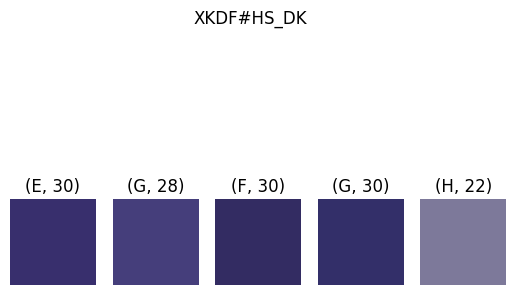

 25%|██▌       | 3/12 [00:10<00:30,  3.39s/it]/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_dista

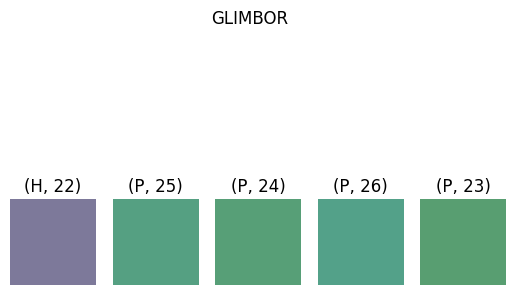

 33%|███▎      | 4/12 [00:13<00:26,  3.37s/it]/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_dista

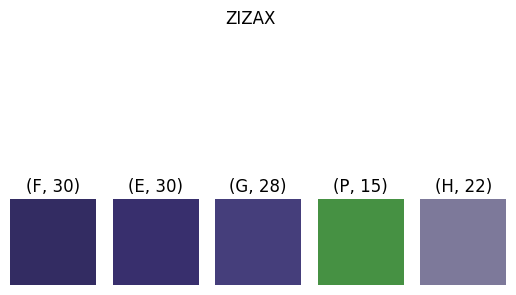

 42%|████▏     | 5/12 [00:16<00:23,  3.36s/it]/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_dista

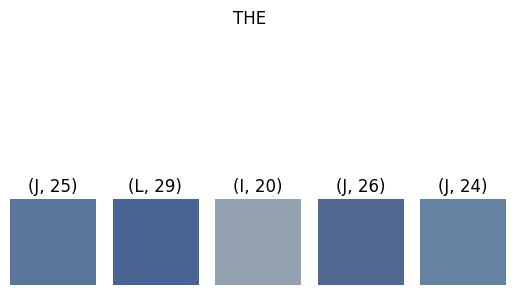

 50%|█████     | 6/12 [00:20<00:20,  3.40s/it]/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_dista

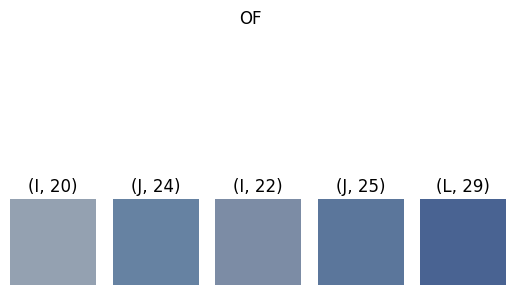

 58%|█████▊    | 7/12 [00:23<00:16,  3.40s/it]/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_dista

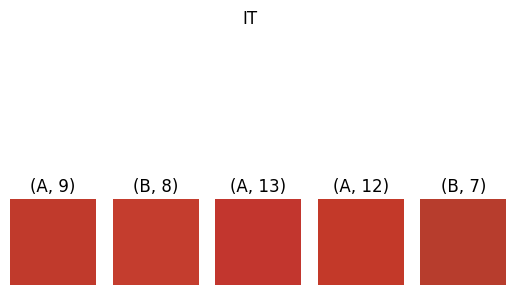

 67%|██████▋   | 8/12 [00:27<00:13,  3.38s/it]/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_dista

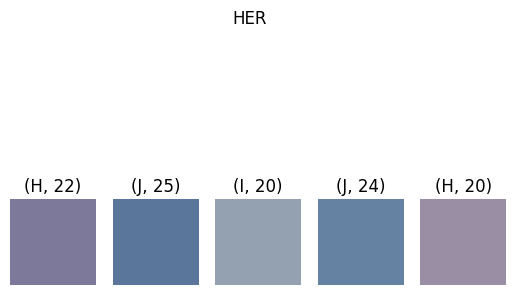

 75%|███████▌  | 9/12 [00:30<00:10,  3.37s/it]/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_dista

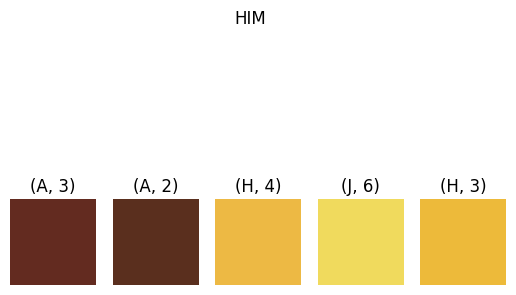

 83%|████████▎ | 10/12 [00:33<00:06,  3.35s/it]/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_dist

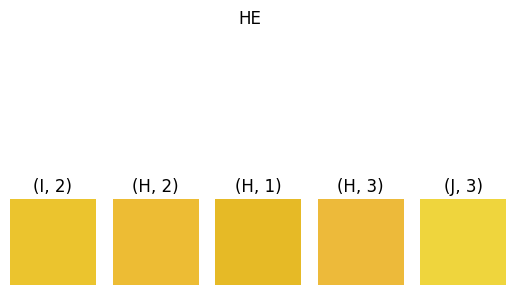

 92%|█████████▏| 11/12 [00:37<00:03,  3.35s/it]/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_distances[j].item()
/tmp/ipykernel_2438956/554831905.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  color_info["distance"] = top5_dist

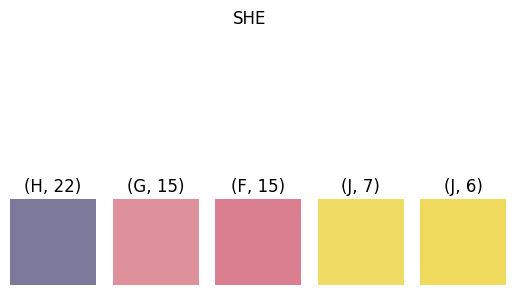

100%|██████████| 12/12 [00:40<00:00,  3.37s/it]


In [6]:
results = defaultdict(list)
show_colors = True
save_fig = False

# Iterate over all the words
it = 0
for word in tqdm(words):
    # Process the images and text
    inputs = processor(text=[word], images=color_images, return_tensors="pt", padding=True)

    # Get embeddings
    with torch.no_grad():
        outputs = model(**inputs)

    text_embeds = outputs.text_embeds
    image_embeds = outputs.image_embeds

    # Normalize embeddings
    text_embeds /= text_embeds.norm(dim=-1, keepdim=True)
    image_embeds /= image_embeds.norm(dim=-1, keepdim=True)

    # Calculate cosine similarity
    cosine_sim = (text_embeds @ image_embeds.T).squeeze(0)

    # Get top 5 colors
    top5_indices = cosine_sim.argsort(descending=True)[:5]
    top5_distances = cosine_sim.sort(descending=True)[0][:5]

    # print(f"Top 5 colors for the word '{word}':")

    if show_colors: fig, axes = plt.subplots(1,5)
    for j, i in enumerate(top5_indices):
        color_info = df_colors.iloc[i.item()]
        color_info["distance"] = top5_distances[j].item()
        results[word].append(color_info.to_dict())
        # print(f"- Coords: ({color_info['coordenada_x']}, {color_info['coordenada_y']}), RGB: ({color_info['R']}, {color_info['G']}, {color_info['B']})")
        if show_colors:
            axes[j].imshow(color_images[i.item()])
            axes[j].axis("off")
            axes[j].set_title(f"({color_info['coordenada_x']}, {color_info['coordenada_y']})")
    if show_colors:
        plt.suptitle(word)
        if save_fig:
            plt.savefig(f"{word}.png", dpi=300)
            plt.close()
        else:
            plt.show()
    it += 1
    # if it == 5: break

In [7]:
flat_data = [
    {**record, 'word':word} 
    for word, records in results.items() 
    for record in records
]

# 2. Create the DataFrame
df = pd.DataFrame(flat_data)

# Optional: Reorder columns to put 'Animal' first
cols = ['word'] + [c for c in df.columns if c != 'word']
df = df[cols]

df.head()

,word,coordenada_x,coordenada_y,R,G,B,distance
0,,J,24,102,130,162,0.231396
1,,J,25,91,118,155,0.230845
2,,I,20,148,161,177,0.230580
3,,I,22,124,140,165,0.230100
4,,J,23,112,144,171,0.229300


In [ ]:
df.to_csv("results_handc_random.csv", index=0)